<a href="https://colab.research.google.com/github/MacUpr/ML/blob/main/CIS_to_MS_ML_SHAP_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practice: Machine Learning Analysis of CIS Conversion to Multiple Sclerosis

## Learning goals

In this practical session, you will work with a clinical tabular dataset about predictors of conversion from **Clinically Isolated Syndrome (CIS)** to **Multiple Sclerosis (MS)**.

By the end of this notebook, students should be able to:

1. Explore a clinical tabular dataset using descriptive statistics and visualizations.
2. Prepare data for machine learning by handling missing values, categorical variables, and numerical scaling.
3. Train and compare several classical machine learning models using **5-fold cross-validation**.
4. Evaluate models using clinically relevant classification metrics.
5. Use **SHAP** to explain global feature importance and feature interactions.

> Important: This notebook is for machine learning education. It is not intended for clinical decision-making.

## 0. Install and import required libraries

Models used in this practice:

| Model | Simple explanation |
|---|---|
| Logistic Regression | Learns a weighted linear combination of features and converts it into a probability. |
| Random Forest | Builds many decision trees and combines their votes. |
| AdaBoost | Builds weak learners sequentially; each new learner focuses more on previous mistakes. |
| SVM | Finds a decision boundary that separates classes with the largest possible margin. |
| CatBoost | Gradient boosting model that handles categorical-style patterns well. |
| XGBoost | Efficient gradient boosting model optimized for predictive performance. |
| LightGBM | Fast gradient boosting model that grows trees efficiently, often useful for tabular data. |

In [ ]:
# Install required packages.
# In Colab, this may take 1-2 minutes.
!pip -q install shap catboost xgboost lightgbm

import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    cross_val_predict
)
from sklearn.metrics import roc_curve, auc
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

import shap

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.5 MB/s eta 0:00:00


## 1. Load the dataset

If you have Kaggle account, download dataset [here](https://www.kaggle.com/datasets/desalegngeb/conversion-predictors-of-cis-to-multiple-sclerosis).

If you do not have Kaggle account, download dataset [here](https://drive.google.com/file/d/1HeOYcJlkPIVX2DvCnk4Pj7bLG9L7RuqV/view?usp=sharing).

Then upload the CSV file to Google Colab. Expected file name:

`conversion_predictors_of_clinically_isolated_syndrome_to_multiple_sclerosis.csv`

The code below first checks whether the file already exists. If not, it asks you to upload it.

In [ ]:
DATA_PATH = "conversion_predictors_of_clinically_isolated_syndrome_to_multiple_sclerosis.csv"

if not os.path.exists(DATA_PATH):
    try:
        from google.colab import files
        uploaded = files.upload()
        DATA_PATH = list(uploaded.keys())[0]
    except Exception:
        raise FileNotFoundError(
            "Dataset file was not found. Please upload the CSV file."
        )

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (273, 20)


,Unnamed: 0,Gender,Age,Schooling,Breastfeeding,Varicella,Initial_Symptom,Mono_or_Polysymptomatic,Oligoclonal_Bands,LLSSEP,ULSSEP,VEP,BAEP,Periventricular_MRI,Cortical_MRI,Infratentorial_MRI,Spinal_Cord_MRI,Initial_EDSS,Final_EDSS,group
0,0,1,34,20.0,1,1,2.0,1,0,1,1,0,0,0,1,0,1,1.0,1.0,1
1,1,1,61,25.0,3,2,10.0,2,1,1,0,1,0,0,0,0,1,2.0,2.0,1
2,2,1,22,20.0,3,1,3.0,1,1,0,0,0,0,0,1,0,0,1.0,1.0,1
3,3,2,41,15.0,1,1,7.0,2,1,0,1,1,0,1,1,0,0,1.0,1.0,1
4,4,2,34,20.0,2,1,6.0,2,0,1,0,0,0,1,0,0,0,1.0,1.0,1


| Feature | Description | Values / Encoding |
|----------|-------------|------------------|
| Age | Age of the patient | Years |
| Schooling | Time spent in school | Years |
| Gender | Patient sex | 1 = Male, 2 = Female |
| Breastfeeding | Breastfeeding history | 1 = Yes, 2 = No, 3 = Unknown |
| Varicella | History of varicella infection | 1 = Positive, 2 = Negative, 3 = Unknown |
| Initial_Symptoms | Initial clinical symptoms | 1 = Visual <br> 2 = Sensory <br> 3 = Motor <br> 4 = Other <br> 5 = Visual + Sensory <br> 6 = Visual + Motor <br> 7 = Visual + Other <br> 8 = Sensory + Motor <br> 9 = Sensory + Other <br> 10 = Motor + Other <br> 11 = Visual + Sensory + Motor <br> 12 = Visual + Sensory + Other <br> 13 = Visual + Motor + Other <br> 14 = Sensory + Motor + Other <br> 15 = Visual + Sensory + Motor + Other |
| Mono_or_Polysymptomatic | Symptom presentation type | 1 = Monosymptomatic, 2 = Polysymptomatic, 3 = Unknown |
| Oligoclonal_Bands | Presence of oligoclonal bands | 0 = Negative, 1 = Positive, 2 = Unknown |
| LLSSEP | Lower Limb Somatosensory Evoked Potentials | 0 = Negative, 1 = Positive |
| ULSSEP | Upper Limb Somatosensory Evoked Potentials | 0 = Negative, 1 = Positive |
| VEP | Visual Evoked Potentials | 0 = Negative, 1 = Positive |
| BAEP | Brainstem Auditory Evoked Potentials | 0 = Negative, 1 = Positive |
| Periventricular_MRI | Periventricular MRI lesions | 0 = Negative, 1 = Positive |
| Cortical_MRI | Cortical MRI lesions | 0 = Negative, 1 = Positive |
| Infratentorial_MRI | Infratentorial MRI lesions | 0 = Negative, 1 = Positive |
| Spinal_Cord_MRI | Spinal cord MRI lesions | 0 = Negative, 1 = Positive |
| initial_EDSS | Expanded Disability Status Scale at baseline | Numeric score |
| final_EDSS | Expanded Disability Status Scale at follow-up | Numeric score |
| Group | Clinical outcome group | 1 = CDMS, 2 = Non-CDMS |

## 2. Basic dataset inspection

Before training models, always inspect:

- number of rows and columns;
- column names;
- data types;
- missing values;
- class distribution of the target variable.

In this dataset, the target column is expected to be `group`.

In [ ]:
TARGET_COL = "group"

if TARGET_COL not in df.columns:
    raise ValueError(
        f"Target column '{TARGET_COL}' was not found. "
        f"Available columns: {df.columns.tolist()}"
    )

# Remove index-like columns and EDSS columns because this cause data leakage.
# All patients that do not have EDSS (NaN) are non-CDMS.
cols_to_drop = [
    col for col in df.columns
    if (col.lower().startswith("unnamed")) or (col.lower().endswith("edss"))
]

if cols_to_drop:
    print("Dropping columns:", cols_to_drop)
    df = df.drop(columns=cols_to_drop)

print("Columns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().to_frame("missing_count"))

print("\nTarget distribution:")
display(df[TARGET_COL].value_counts().to_frame("count"))

print("\nTarget distribution in percentage:")
display(
    (df[TARGET_COL].value_counts(normalize=True) * 100)
    .round(2)
    .to_frame("percentage")
)

Dropping columns: ['Unnamed: 0', 'Initial_EDSS', 'Final_EDSS']
Columns:
['Gender', 'Age', 'Schooling', 'Breastfeeding', 'Varicella', 'Initial_Symptom', 'Mono_or_Polysymptomatic', 'Oligoclonal_Bands', 'LLSSEP', 'ULSSEP', 'VEP', 'BAEP', 'Periventricular_MRI', 'Cortical_MRI', 'Infratentorial_MRI', 'Spinal_Cord_MRI', 'group']

Data types:


,dtype
Gender,int64
Age,int64
Schooling,float64
Breastfeeding,int64
Varicella,int64
Initial_Symptom,float64
Mono_or_Polysymptomatic,int64
Oligoclonal_Bands,int64
LLSSEP,int64
ULSSEP,int64



Missing values:


,missing_count
Gender,0
Age,0
Schooling,1
Breastfeeding,0
Varicella,0
Initial_Symptom,1
Mono_or_Polysymptomatic,0
Oligoclonal_Bands,0
LLSSEP,0
ULSSEP,0



Target distribution:


,count
group,
2,148
1,125



Target distribution in percentage:


,percentage
group,
2,54.21
1,45.79


# Section A: Exploratory Data Analysis

EDA helps us understand the dataset before model training.

We will examine:

1. Summary statistics.
2. Missing values.
3. Class balance.
4. Feature distributions.
5. Correlations between numerical features.

In [ ]:
# Summary statistics for numerical columns.
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Gender,273.0,1.615385,0.487398,1.0,1.0,2.0,2.0,2.0
Age,273.0,34.062271,11.114369,15.0,25.0,33.0,40.0,77.0
Schooling,272.0,15.176471,4.244175,0.0,12.0,15.0,20.0,25.0
Breastfeeding,273.0,1.831502,0.874998,1.0,1.0,2.0,3.0,3.0
Varicella,273.0,1.710623,0.732991,1.0,1.0,2.0,2.0,3.0
Initial_Symptom,272.0,6.430147,4.222009,1.0,3.0,6.0,9.0,15.0
Mono_or_Polysymptomatic,273.0,1.725275,0.494066,1.0,1.0,2.0,2.0,3.0
Oligoclonal_Bands,273.0,0.358974,0.558426,0.0,0.0,0.0,1.0,2.0
LLSSEP,273.0,0.424908,0.495237,0.0,0.0,0.0,1.0,1.0
ULSSEP,273.0,0.369963,0.483681,0.0,0.0,0.0,1.0,1.0


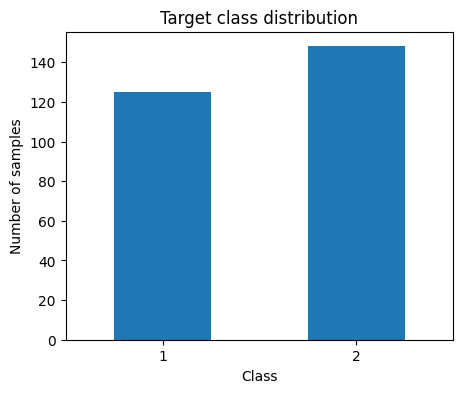

In [ ]:
# Visualize target class distribution.
plt.figure(figsize=(5, 4))
df[TARGET_COL].value_counts().sort_index().plot(kind="bar")
plt.title("Target class distribution")
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.xticks(rotation=0)
plt.show()

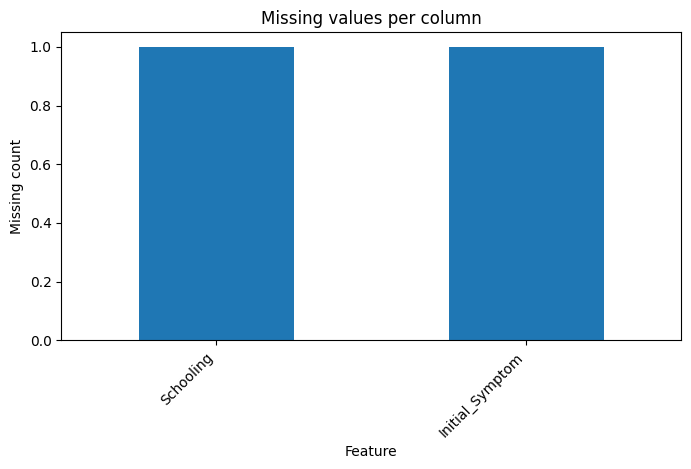

In [ ]:
# Missing value visualization.
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_counts = missing_counts[missing_counts > 0]

if len(missing_counts) == 0:
    print("No missing values were found.")
else:
    plt.figure(figsize=(8, 4))
    missing_counts.plot(kind="bar")
    plt.title("Missing values per column")
    plt.xlabel("Feature")
    plt.ylabel("Missing count")
    plt.xticks(rotation=45, ha="right")
    plt.show()

In [ ]:
# Separate features and target for EDA.
X_raw = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Identify categorical and numerical columns.
numerical_cols = ["Age", "Schooling"]
categorical_cols = X_raw.columns.difference(numerical_cols).tolist()

print("Categorical columns:")
print(categorical_cols)

print("Numerical columns:")
print(numerical_cols)

Categorical columns:
['BAEP', 'Breastfeeding', 'Cortical_MRI', 'Gender', 'Infratentorial_MRI', 'Initial_Symptom', 'LLSSEP', 'Mono_or_Polysymptomatic', 'Oligoclonal_Bands', 'Periventricular_MRI', 'Spinal_Cord_MRI', 'ULSSEP', 'VEP', 'Varicella']
Numerical columns:
['Age', 'Schooling']


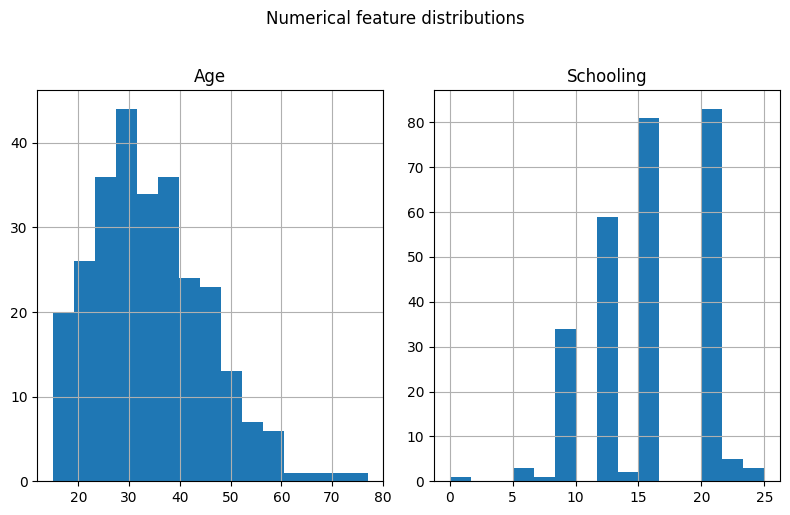

In [ ]:
# Histograms for numerical features.
if len(numerical_cols) > 0:
    X_raw[numerical_cols].hist(figsize=(8, 5), bins=15)
    plt.suptitle("Numerical feature distributions", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns detected.")

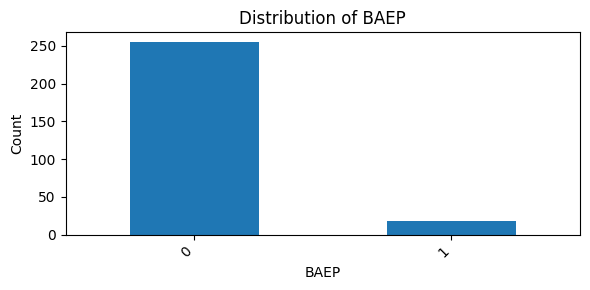

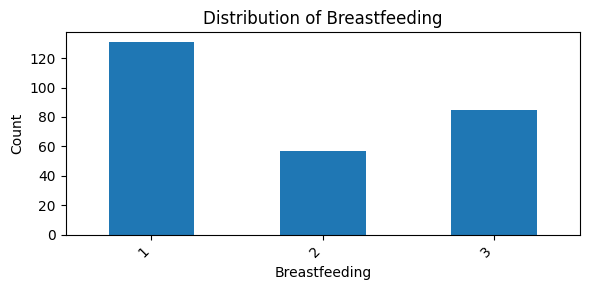

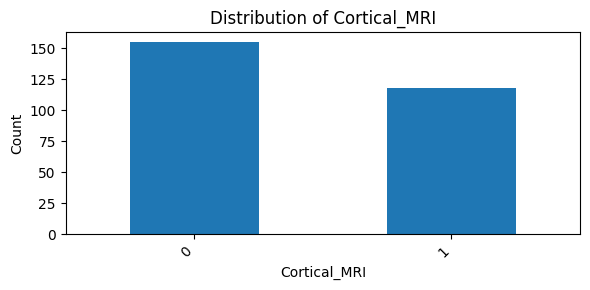

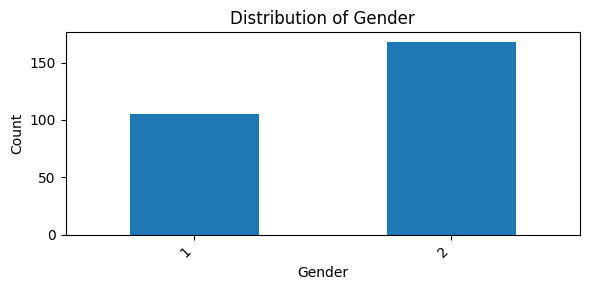

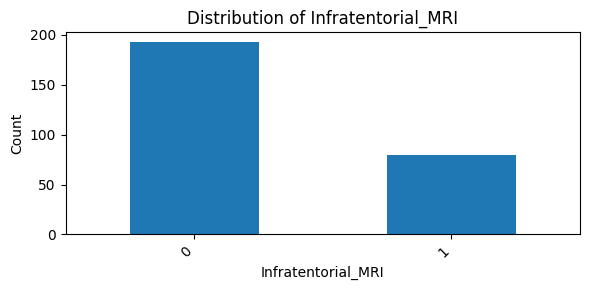

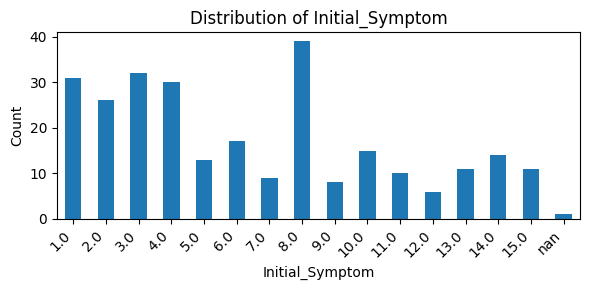

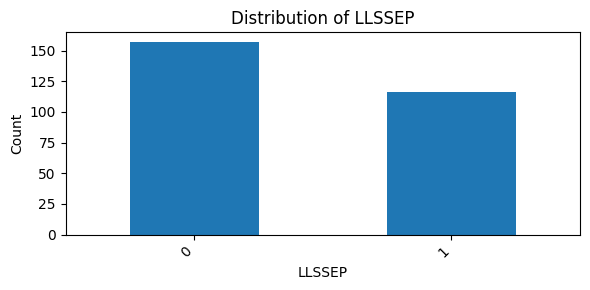

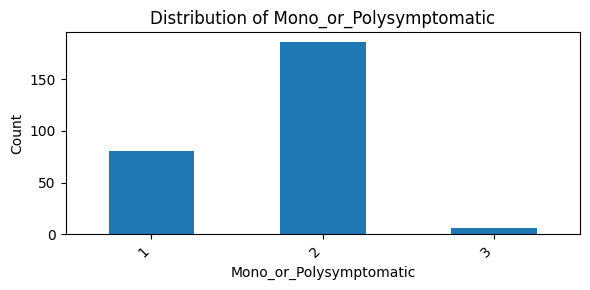

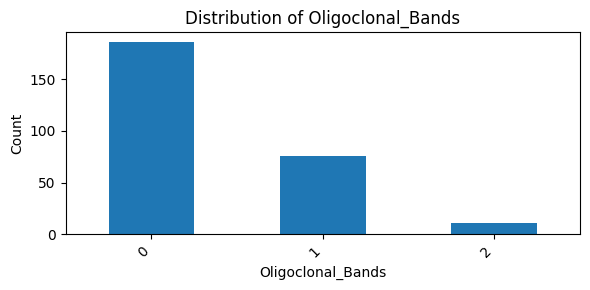

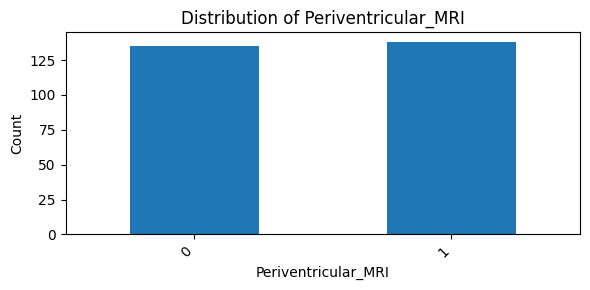

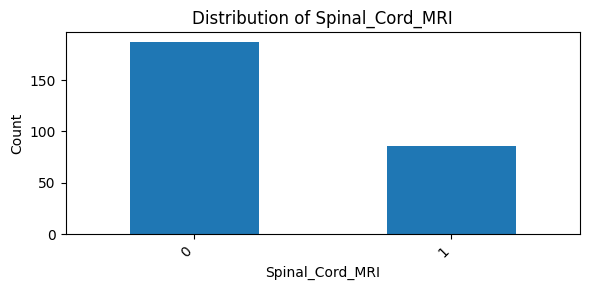

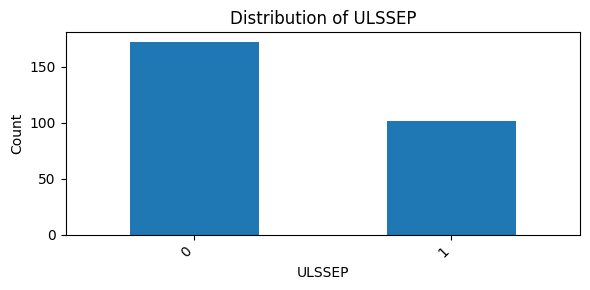

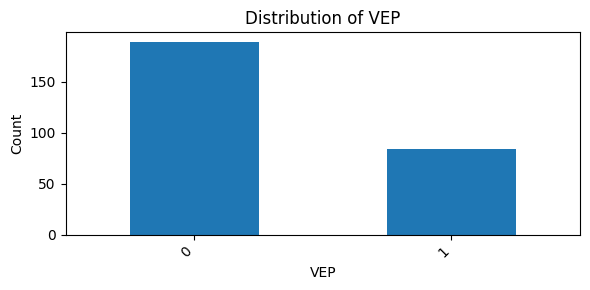

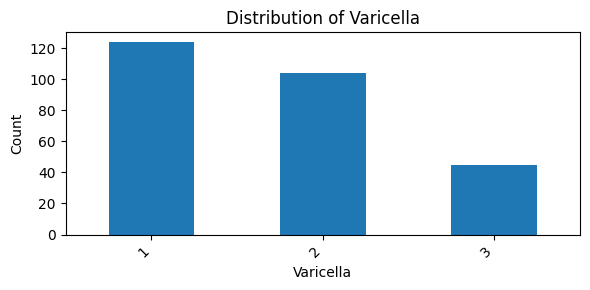

In [ ]:
# Bar plots for categorical features.
for col in categorical_cols:
    plt.figure(figsize=(6, 3))
    df[col].value_counts(dropna=False).sort_index().plot(kind="bar")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

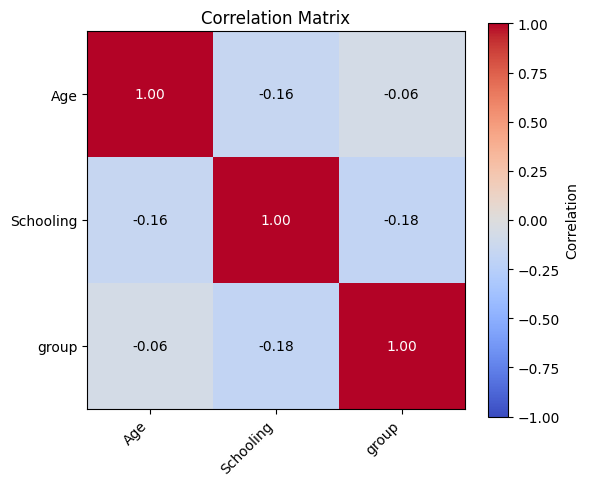

In [ ]:
# Correlation matrix for numerical columns.
if len(numerical_cols) >= 2:
    corr = df[numerical_cols + [TARGET_COL]].corr()

    plt.figure(figsize=(6, 5))
    im = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    plt.colorbar(im, label="Correlation")

    plt.xticks(
        range(len(corr.columns)),
        corr.columns,
        rotation=45,
        ha="right"
    )
    plt.yticks(range(len(corr.index)), corr.index)

    # Add correlation values inside cells
    for i in range(len(corr.index)):
        for j in range(len(corr.columns)):
            value = corr.iloc[i, j]
            plt.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                color="white" if abs(value) > 0.5 else "black",
            )

    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.show()

else:
    print("Not enough numerical columns for a correlation matrix.")

# Section B: Preprocessing for Model Training

Machine learning models require clean numerical input.

The preprocessing pipeline will:

1. Impute missing numerical values using the median.
2. Normalize numerical features using standard scaling.
3. Impute missing categorical values using the most frequent category.
4. Convert categorical values into one-hot encoded features.

We use a `Pipeline` and `ColumnTransformer` so preprocessing is fitted only on the training folds during cross-validation.  
This avoids data leakage.

In [ ]:
X = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL].copy()

# Convert label 2 (non-CDMS) to 0.
y = y.replace(2, 0)

# Convert Gender to binary (1 - Male, 0 - Female)
X['Gender'] = X["Gender"].replace(2, 0)

print("Target labels after mapping:", sorted(y.dropna().unique()))

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numerical_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ],
    remainder="drop",
)

print(f"Categorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")

Target labels after mapping: [np.int64(0), np.int64(1)]
Categorical columns: ['BAEP', 'Breastfeeding', 'Cortical_MRI', 'Gender', 'Infratentorial_MRI', 'Initial_Symptom', 'LLSSEP', 'Mono_or_Polysymptomatic', 'Oligoclonal_Bands', 'Periventricular_MRI', 'Spinal_Cord_MRI', 'ULSSEP', 'VEP', 'Varicella']
Numerical columns: ['Age', 'Schooling']


# Section C: Train Models with 5-Fold Cross-Validation

We will train and compare seven models:


## Linear Models

**Logistic Regression**

Logistic Regression is a linear classifier.
It assigns a weight to each feature, combines them linearly, and converts the result into a probability using a logistic function.


## Support Vector Machines

**Support Vector Machine (SVM)**

SVM finds a decision boundary that maximizes the separation (margin) between classes.
Using kernel functions, it can model both linear and non-linear relationships.


## Ensemble Tree-Based Models

**Random Forest (Bagging)**

Random Forest builds many decision trees independently using different subsets of the data.
The final prediction is obtained by combining the predictions of all trees through majority voting.


## Boosting-Based Tree Ensembles

**AdaBoost**

AdaBoost trains weak learners sequentially.
Each new learner focuses more on samples that were misclassified by previous learners.

**CatBoost**

CatBoost is a gradient boosting algorithm that builds trees sequentially.
Each new tree attempts to correct the errors made by the previous trees.
It is designed to handle categorical features effectively.

**XGBoost**

XGBoost is an optimized gradient boosting algorithm.
It incorporates regularization and efficient training strategies to achieve strong performance on tabular datasets.

**LightGBM**

LightGBM is a gradient boosting algorithm optimized for speed and scalability.
It uses a leaf-wise tree growth strategy to efficiently handle large datasets.

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "AdaBoost": AdaBoostClassifier(
        n_estimators=200,
        learning_rate=0.05,
        random_state=RANDOM_STATE,
    ),
    "SVM": SVC(
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "CatBoost": CatBoostClassifier(
        iterations=300,
        learning_rate=0.03,
        depth=4,
        loss_function="Logloss",
        verbose=False,
        random_seed=RANDOM_STATE,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=-1,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        verbose=-1,
    ),
}

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

In [ ]:
cv_results = []
roc_results = {}

for model_name, model in models.items():
    print(f"Training: {model_name}")

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    # Evaluation metrics
    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        error_score="raise",
    )

    result = {"model": model_name}

    for metric_name in scoring.keys():
        values = scores[f"test_{metric_name}"]

        result[f"{metric_name}_mean"] = values.mean()
        result[f"{metric_name}_std"] = values.std()


    # Probabilities to plot ROC curve
    y_prob = cross_val_predict(
        pipeline,
        X,
        y,
        cv=cv,
        method="predict_proba",
        n_jobs=-1,
    )[:, 1]

    fpr, tpr, _ = roc_curve(
        y,
        y_prob,
    )

    roc_auc = auc(fpr, tpr)

    roc_results[model_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": roc_auc,
    }

    cv_results.append(result)

results_df = pd.DataFrame(cv_results)

results_df = results_df.sort_values(
    by="roc_auc_mean",
    ascending=False,
)

display(results_df.round(3))

Training: Logistic Regression
Training: Random Forest
Training: AdaBoost
Training: SVM
Training: CatBoost
Training: XGBoost
Training: LightGBM


,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std
4,CatBoost,0.854,0.044,0.839,0.039,0.840,0.072,0.839,0.053,0.910,0.026,0.895,0.021
5,XGBoost,0.809,0.025,0.784,0.023,0.808,0.073,0.794,0.036,0.902,0.023,0.885,0.018
0,Logistic Regression,0.809,0.048,0.799,0.061,0.784,0.074,0.790,0.055,0.901,0.039,0.887,0.043
1,Random Forest,0.802,0.022,0.766,0.029,0.824,0.074,0.791,0.030,0.892,0.029,0.879,0.032
6,LightGBM,0.824,0.050,0.781,0.037,0.856,0.103,0.814,0.061,0.892,0.023,0.870,0.022
3,SVM,0.802,0.043,0.759,0.038,0.832,0.064,0.793,0.047,0.891,0.028,0.868,0.021
2,AdaBoost,0.773,0.053,0.764,0.053,0.728,0.078,0.745,0.063,0.882,0.036,0.860,0.040


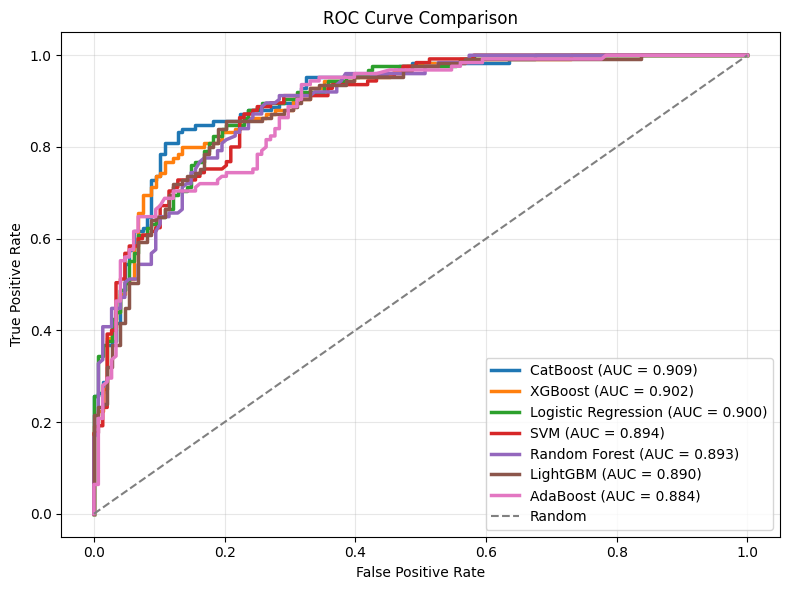

In [ ]:
plt.figure(figsize=(8, 6))

for model_name, data in sorted(
    roc_results.items(),
    key=lambda x: x[1]["auc"],
    reverse=True,
):
    plt.plot(
        data["fpr"],
        data["tpr"],
        lw=2.5,
        label=f"{model_name} (AUC = {data['auc']:.3f})",
    )

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    color="gray",
    label="Random",
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

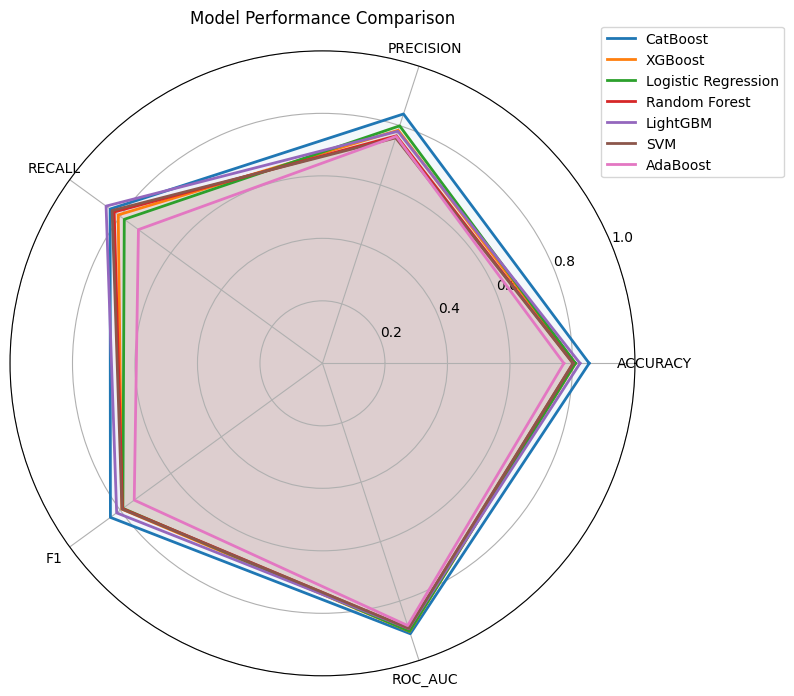

In [ ]:
# Radar chart
metrics = [
    "accuracy_mean",
    "precision_mean",
    "recall_mean",
    "f1_mean",
    "roc_auc_mean",
]

labels = [m.replace("_mean", "").upper() for m in metrics]

num_metrics = len(metrics)

angles = np.linspace(
    0,
    2 * np.pi,
    num_metrics,
    endpoint=False,
).tolist()

angles += angles[:1]

fig, ax = plt.subplots(
    figsize=(8, 8),
    subplot_kw=dict(polar=True),
)

for _, row in results_df.iterrows():

    values = row[metrics].tolist()

    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=row["model"],
    )

    ax.fill(
        angles,
        values,
        alpha=0.05,
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

ax.set_ylim(0, 1)

ax.set_title(
    "Model Performance Comparison",
    pad=20,
)

ax.legend(
    bbox_to_anchor=(1.25, 1.05),
)

plt.tight_layout()
plt.show()

## Model comparison questions for students

Answer these questions after running the cross-validation:

1. Which model has the highest ROC-AUC?
2. Which model has the highest recall?
3. If missing positive conversion cases is clinically costly, which metric should receive more attention?
4. Is the best model much better than the simpler Logistic Regression model?
5. Are the results stable across folds? Look at the standard deviation.

# Section D: SHAP Feature Importance and Feature Interactions

SHAP helps explain model predictions. Read more about SHAP [here](https://shap.readthedocs.io/en/latest/example_notebooks/overviews/An%20introduction%20to%20explainable%20AI%20with%20Shapley%20values.html).

In this section, we will:

1. Fit the best-performing model on the full dataset.
2. Transform the dataset using the preprocessing pipeline.
3. Compute SHAP values.
4. Visualize global feature importance.
5. Visualize feature effects.
6. Explore feature interactions.

In this practice, we use the best model based on mean ROC-AUC.

In [ ]:
best_model_name = results_df.iloc[0]["model"]
best_model = models[best_model_name]

print("Best model based on mean ROC-AUC:", best_model_name)

best_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", best_model),
    ]
)

best_pipeline.fit(X, y)
print("Best pipeline fitted.")

Best model based on mean ROC-AUC: CatBoost
Best pipeline fitted.


In [ ]:
# Get transformed feature matrix and feature names.
fitted_preprocessor = best_pipeline.named_steps["preprocessor"]
fitted_model = best_pipeline.named_steps["model"]

X_transformed = fitted_preprocessor.transform(X)

if hasattr(X_transformed, "toarray"):
    X_transformed = X_transformed.toarray()

feature_names = fitted_preprocessor.get_feature_names_out()
feature_names = [
    name.replace("num__", "").replace("cat__", "")
    for name in feature_names
]

X_transformed_df = pd.DataFrame(
    X_transformed,
    columns=feature_names,
)

display(X_transformed_df.head())
print("Transformed feature shape:", X_transformed_df.shape)

,Age,Schooling,BAEP_0.0,BAEP_1.0,Breastfeeding_1.0,Breastfeeding_2.0,Breastfeeding_3.0,Cortical_MRI_0.0,Cortical_MRI_1.0,Gender_0.0,...,Periventricular_MRI_1.0,Spinal_Cord_MRI_0.0,Spinal_Cord_MRI_1.0,ULSSEP_0.0,ULSSEP_1.0,VEP_0.0,VEP_1.0,Varicella_1.0,Varicella_2.0,Varicella_3.0
0,-0.005613,1.140841,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
1,2.428136,2.323262,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
2,-1.087279,1.140841,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
3,0.625359,-0.041580,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,...,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
4,-0.005613,1.140841,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


Transformed feature shape: (273, 47)


In [ ]:
# Compute SHAP values.
# TreeExplainer works well for tree-based models.
# For non-tree models, we use a general SHAP Explainer with prediction probability.

tree_model_names = [
    "Random Forest",
    "AdaBoost",
    "CatBoost",
    "XGBoost",
    "LightGBM",
]

# sample_size = min(150, X_transformed_df.shape[0])
# X_shap = X_transformed_df.sample(
#     n=sample_size,
#     random_state=RANDOM_STATE,
# )

X_shap = X_transformed_df.copy()

if best_model_name in tree_model_names:
    masker = shap.maskers.Independent(
        X_transformed_df,
        max_samples=X_transformed_df.shape[0],
    )

    explainer = shap.Explainer(
        fitted_model,
        masker,
    )

    shap_values = explainer(X_shap)

    if len(shap_values.values.shape) == 3:
        shap_values.values = shap_values.values[:, :, 1]
else:
    background = shap.sample(
        X_transformed_df,
        min(80, X_transformed_df.shape[0]),
        random_state=RANDOM_STATE,
    )

    explainer = shap.Explainer(
        fitted_model.predict_proba,
        background,
    )

    shap_values = explainer(X_shap)

    if len(shap_values.values.shape) == 3:
        shap_values.values = shap_values.values[:, :, 1]

print("SHAP values shape:", shap_values.values.shape)

SHAP values shape: (273, 47)


## Global SHAP feature importance

The global SHAP bar plot shows which features have the strongest average influence on the model predictions.

A larger mean absolute SHAP value means the feature usually changes the prediction more strongly.

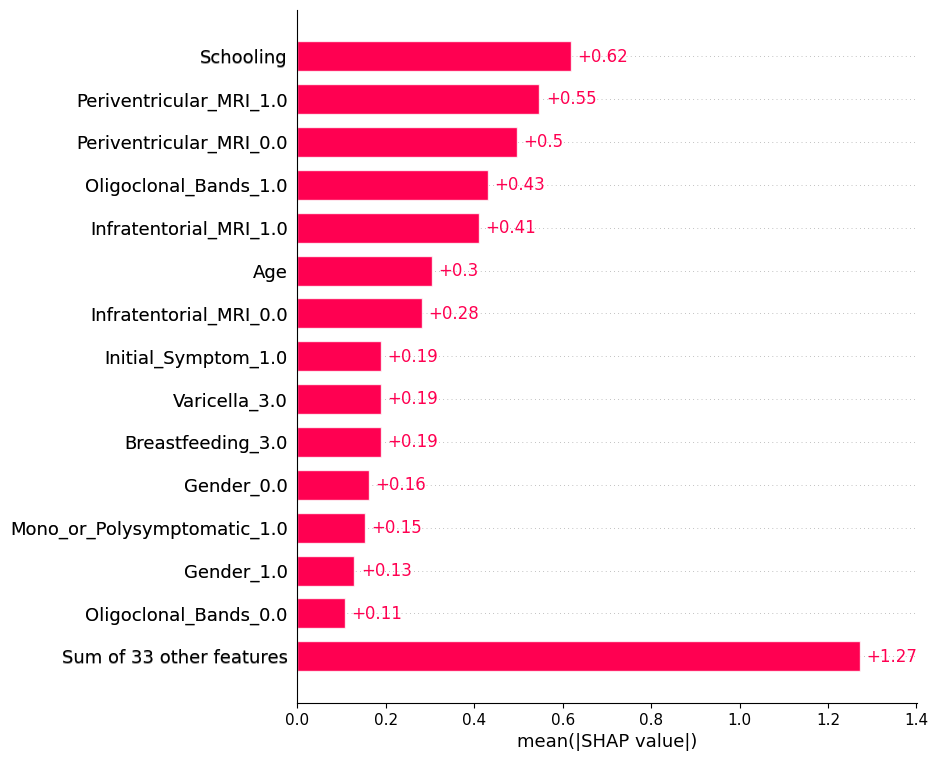

In [ ]:
shap.plots.bar(shap_values, max_display=15)

## SHAP beeswarm plot

The beeswarm plot shows both:

- the importance of each feature;
- whether high or low values push predictions upward or downward.

Each dot is one patient/sample.

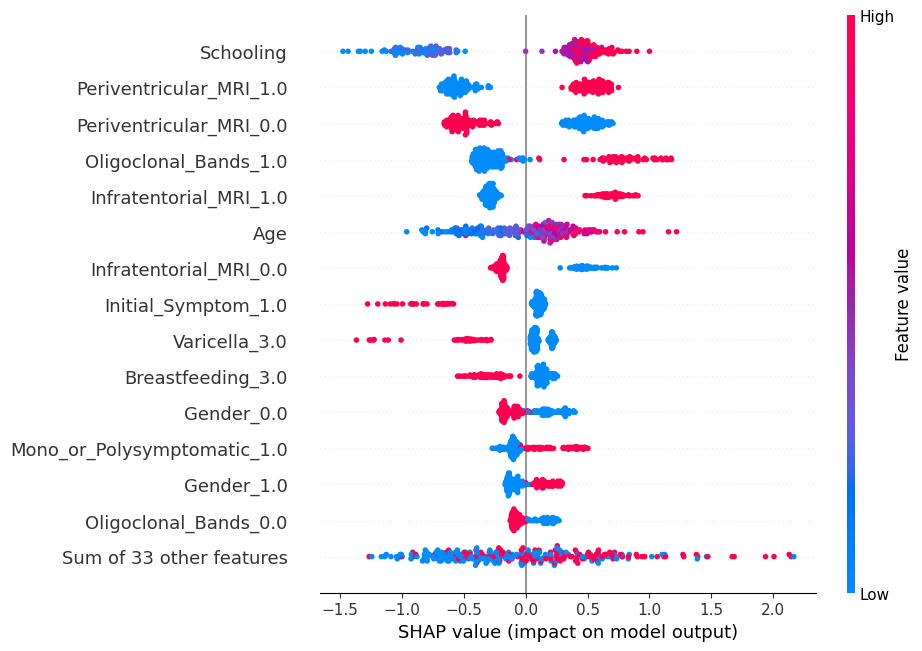

In [ ]:
shap.plots.beeswarm(shap_values, max_display=15)

## SHAP dependence plots

A dependence plot shows how one feature affects model predictions.

The x-axis is the feature value.  
The y-axis is the SHAP value for that feature.

Positive SHAP values push the prediction toward class 1.  
Negative SHAP values push the prediction toward class 0.

In [ ]:
# Select top features by mean absolute SHAP value.
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

importance_df = pd.DataFrame(
    {
        "feature": X_shap.columns,
        "mean_abs_shap": mean_abs_shap,
    }
).sort_values("mean_abs_shap", ascending=False)

display(importance_df.head(15))

top_features = importance_df["feature"].head(3).tolist()
print("Top features selected for dependence plots:")
print(top_features)

,feature,mean_abs_shap
1,Schooling,0.619081
37,Periventricular_MRI_1.0,0.546796
36,Periventricular_MRI_0.0,0.496319
34,Oligoclonal_Bands_1.0,0.431184
12,Infratentorial_MRI_1.0,0.409975
0,Age,0.304613
11,Infratentorial_MRI_0.0,0.281116
13,Initial_Symptom_1.0,0.188891
46,Varicella_3.0,0.188338
6,Breastfeeding_3.0,0.188237


Top features selected for dependence plots:
['Schooling', 'Periventricular_MRI_1.0', 'Periventricular_MRI_0.0']


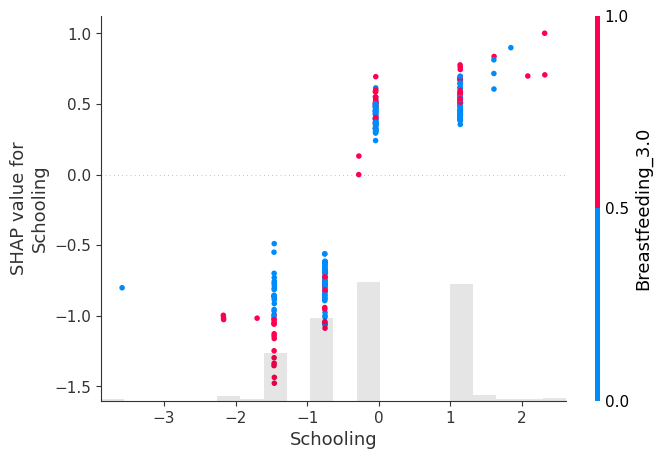

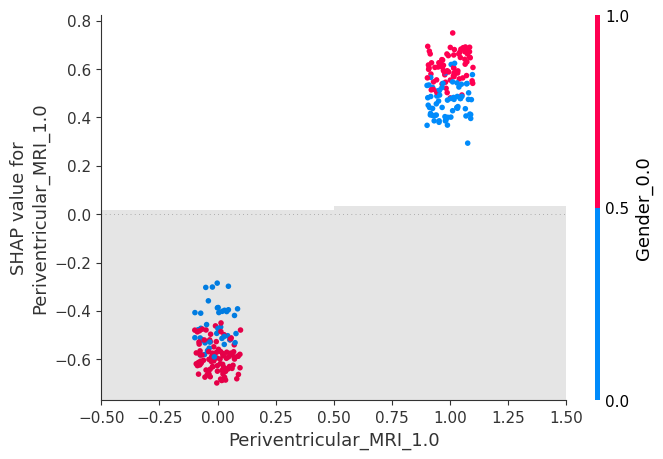

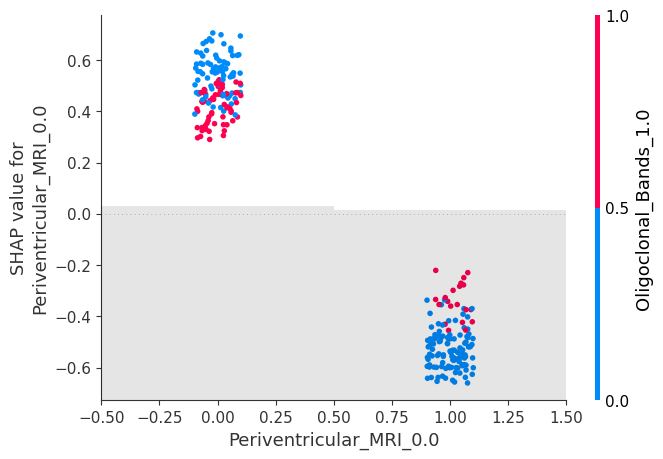

In [ ]:
# Dependence plots for top features.
for feature in top_features:
    shap.plots.scatter(
        shap_values[:, feature],
        color=shap_values,
    )

## SHAP interaction analysis

Feature interaction means that the effect of one feature depends on another feature.

Example:  
A clinical test may be more informative for one age group than another.

For tree-based models, SHAP can estimate interaction values directly.  
For other models, we approximate interactions by using SHAP dependence plots colored by another important feature.

,feature_1,feature_2,mean_abs_interaction
1644,Oligoclonal_Bands_1.0,Varicella_3.0,0.068184
1634,Oligoclonal_Bands_1.0,Periventricular_MRI_0.0,0.047875
283,Breastfeeding_3.0,Schooling,0.046469
735,Initial_Symptom_3.0,Mono_or_Polysymptomatic_1.0,0.045011
1,Age,Schooling,0.036927
782,Initial_Symptom_4.0,Mono_or_Polysymptomatic_1.0,0.035360
8,Age,Cortical_MRI_1.0,0.034094
460,Gender_0.0,Periventricular_MRI_1.0,0.032362
7,Age,Cortical_MRI_0.0,0.028838
459,Gender_0.0,Periventricular_MRI_0.0,0.024945


Top interaction pair: Oligoclonal_Bands_1.0 and Varicella_3.0


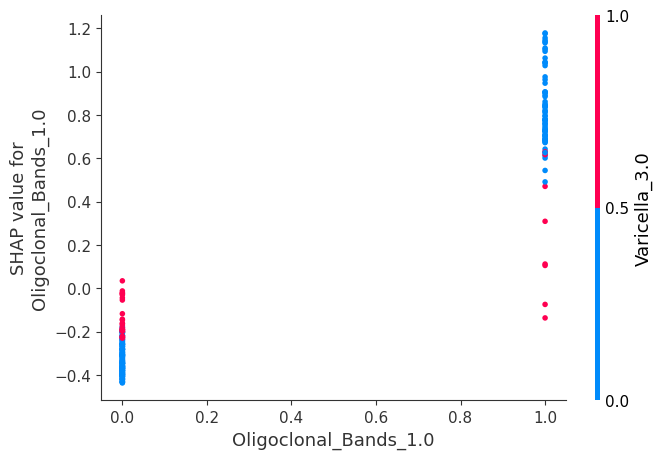

In [ ]:
if best_model_name in ["Random Forest", "CatBoost", "XGBoost", "LightGBM"]:
    try:
        tree_explainer = shap.TreeExplainer(fitted_model)
        interaction_values = tree_explainer.shap_interaction_values(X_shap)

        if isinstance(interaction_values, list):
            interaction_values = interaction_values[1]

        if len(np.array(interaction_values).shape) == 4:
            interaction_values = interaction_values[:, :, :, 1]

        interaction_strength = np.abs(interaction_values).mean(axis=0)

        np.fill_diagonal(interaction_strength, 0)

        interaction_df = (
            pd.DataFrame(
                interaction_strength,
                index=X_shap.columns,
                columns=X_shap.columns,
            )
            .stack()
            .reset_index()
        )

        interaction_df.columns = [
            "feature_1",
            "feature_2",
            "mean_abs_interaction",
        ]

        interaction_df = interaction_df[
            interaction_df["feature_1"] < interaction_df["feature_2"]
        ]

        interaction_df = interaction_df.sort_values(
            "mean_abs_interaction",
            ascending=False,
        )

        display(interaction_df.head(10))

        top_pair = interaction_df.iloc[0]
        f1 = top_pair["feature_1"]
        f2 = top_pair["feature_2"]

        print("Top interaction pair:", f1, "and", f2)

        shap.dependence_plot(
            f1,
            shap_values.values,
            X_shap,
            interaction_index=f2,
            show=True,
        )

    except Exception as error:
        print("Direct SHAP interaction calculation failed.")
        print("Reason:", error)
        print("Using dependence plot approximation instead.")

        if len(top_features) >= 2:
            shap.dependence_plot(
                top_features[0],
                shap_values.values,
                X_shap,
                interaction_index=top_features[1],
                show=True,
            )
else:
    if len(top_features) >= 2:
        print(
            "Best model is not tree-based. "
            "Using dependence plot as an interaction approximation."
        )

        shap.dependence_plot(
            top_features[0],
            shap_values.values,
            X_shap,
            interaction_index=top_features[1],
            show=True,
        )

## Optional: Compare model-specific feature importance

Some tree-based models also provide built-in feature importance.  
This is not the same as SHAP, but it is useful for comparison.

SHAP is usually more informative because it explains how features affect predictions and can show direction of effect.

,feature,importance
37,Periventricular_MRI_1.0,9.792557
1,Schooling,9.644920
0,Age,8.901871
34,Oligoclonal_Bands_1.0,8.479025
36,Periventricular_MRI_0.0,8.226383
12,Infratentorial_MRI_1.0,6.189335
46,Varicella_3.0,4.262541
11,Infratentorial_MRI_0.0,4.039424
13,Initial_Symptom_1.0,3.287534
6,Breastfeeding_3.0,3.146749


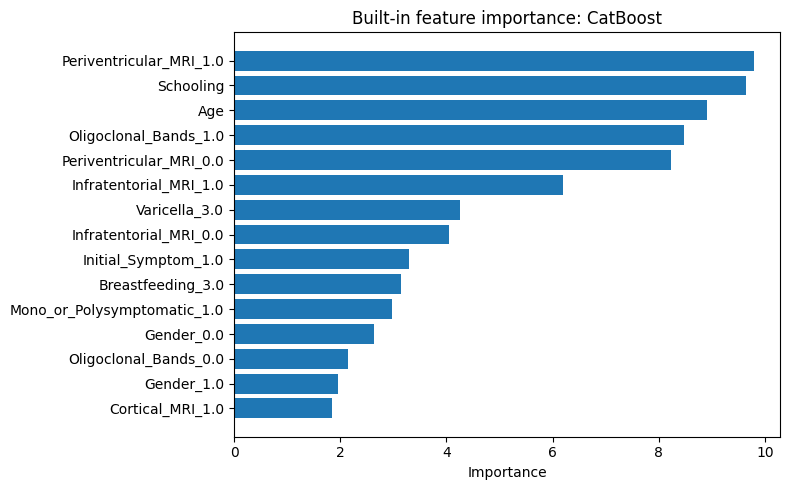

In [ ]:
if hasattr(fitted_model, "feature_importances_"):
    model_importance_df = pd.DataFrame(
        {
            "feature": X_transformed_df.columns,
            "importance": fitted_model.feature_importances_,
        }
    ).sort_values("importance", ascending=False)

    display(model_importance_df.head(15))

    plt.figure(figsize=(8, 5))
    plot_df = model_importance_df.head(15).sort_values(
        "importance",
        ascending=True,
    )
    plt.barh(plot_df["feature"], plot_df["importance"])
    plt.title(f"Built-in feature importance: {best_model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} does not provide built-in feature_importances_.")

# Final student reflection

Write a short reflection using the following structure:

1. **Best model:** Which model performed best and according to which metric?
2. **Clinical interpretation:** Which features were most important according to SHAP?
3. **Feature interactions:** Did you observe any meaningful interaction between features?
4. **Model reliability:** Are the results stable enough across 5 folds?
5. **Limitations:** What are the main limitations of this dataset and analysis?

Suggested limitations to consider:

- small dataset size;
- possible encoded categorical variables without full category labels;
- no external validation dataset;
- SHAP explains model behavior, not necessarily causal clinical relationships.

# Additional exercises

Students who finish early can try:

1. Change the categorical feature threshold from 10 unique values to another value.
2. Remove one group of features and repeat model training.
3. Tune hyperparameters for the best model.
4. Compare SHAP results from two different models.
5. Use only clinically simple features and compare performance.